# 1D CNN — Two-Hand Dynamic Gesture Recognition

Clean, single-path pipeline for training a 1D CNN on the glove data.

**Pipeline stages**
1. Configuration (data paths, sensor selection, preprocessing, augmentation, training)
2. Sensor column selection
3. Load CSVs from `DynamicTrainingData/TwoSec`
4. Preprocess: resample to fixed length + Butterworth low-pass filter
5. Train/test split (hold-out)
6. Cross-validation with augmentation **inside** each fold (so the validation set is never augmented)
7. Final retrain on the full training pool and evaluation on hold-out
8. Batch test on `TestData/Jestin/TwoHandDynamic` using per-subfolder labels
9. Save model + log experiment row

Only the CNN-on-sequences path is supported here. Engineered-feature/MLP variants have been removed to keep the notebook readable.


## 1. Imports


In [1]:
import os
import re
import glob
import json
import hashlib
import warnings
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal as scipy_signal
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.max_columns', 20)
print('Imports OK.')


I0000 00:00:1777863363.915205  143529 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777863363.918081  143529 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777863364.179493  143529 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777863365.460686  143529 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENAB

Imports OK.


## 2. Configuration

All knobs in one place. Edit only this cell to run different experiments.


In [2]:
# ── Data locations ───────────────────────────────────────────────────────────
DATA_ROOT       = '/home/jestin/ThesisRepo/ML/NewTrainingData/Dynamic'
BATCH_TEST_ROOT = '/home/jestin/ThesisRepo/ML/NewTestData/Tash/Dynamic'
INCLUDE_LABELS  = None   # None = use every label subfolder under DATA_ROOT

# ── Sensor selection ─────────────────────────────────────────────────────────
USE_LEFT_HAND  = True
USE_RIGHT_HAND = True

USE_YPR        = True   # yaw / pitch / roll (or heading/pitch/roll for wrist)
USE_QUAT       = False   # quaternion w/x/y/z
USE_ACCEL      = True   # ax / ay / az
USE_FLEX       = True   # mcp_flex / pip_flex (fingers only)

# Segments to include
USE_WRIST  = True
USE_PALM   = True
USE_THUMB  = True
USE_INDEX  = True
USE_MIDDLE = True
USE_RING   = True
USE_PINKY  = True

# ── Preprocessing ────────────────────────────────────────────────────────────
RESAMPLE_TO_N_STEPS    = 90
APPLY_BUTTERWORTH      = True
BUTTERWORTH_CUTOFF_HZ  = 10.0
BUTTERWORTH_ORDER      = 4
SAMPLING_RATE_HZ       = 30.0
NORMALISATION          = 'minmax'   # 'standard' | 'minmax' | None

# ── Train/test split ─────────────────────────────────────────────────────────
TEST_SIZE             = 0.10
RANDOM_STATE          = 42
STRATIFY_SPLIT        = True

# ── Cross-validation ─────────────────────────────────────────────────────────
RUN_CROSS_VALIDATION  = True
CV_FOLDS              = 5
CV_SHUFFLE            = True

# ── Augmentation (training only, inside each CV fold) ────────────────────────
AUGMENT_TRAINING_DATA          = True
AUGMENTATION_COPIES_PER_SAMPLE = 5
AUGMENTATION_RANDOM_SEED       = 42
AUGMENT_CONFIG = {
    'time_shift':      {'enabled': False,  'apply_prob': 0.7, 'max_shift_steps': 3, 'fill_mode': 'edge'},
    'time_warp':       {'enabled': False,  'apply_prob': 0.5, 'speed_range': (0.90, 1.10)},
    'time_mask':       {'enabled': False,  'apply_prob': 0.5, 'max_masks': 2, 'max_mask_size': 3, 'fill_mode': 'zero'},
    'gaussian_noise':  {'enabled': False,  'apply_prob': 1.0, 'std_ratio': 0.02},
    'amplitude_scale': {'enabled': True,  'apply_prob': 0.5, 'scale_range': (0.95, 1.05)},
    'baseline_offset': {'enabled': True,  'apply_prob': 0.5, 'offset_std_ratio': 0.02},
    'channel_dropout': {'enabled': False,  'apply_prob': 0.3, 'drop_fraction': 0.03, 'fill_mode': 'zero'},
    # Only enable left/right swap if the class label is symmetric under that swap
    'left_right_swap': {'enabled': False, 'apply_prob': 0.5},
}

# ── Training hyperparameters ─────────────────────────────────────────────────
TRAIN_EPOCHS           = 15
TRAIN_BATCH_SIZE       = 16
TRAIN_VALIDATION_SPLIT = 0.2   # only used by the final retrain (not by CV)
TRAIN_VERBOSE          = 1

# ── Output paths ─────────────────────────────────────────────────────────────
MODEL_OUTPUT_DIR     = Path('saved_models')
EXPERIMENT_LOG_PATH  = MODEL_OUTPUT_DIR / 'experiment_results.csv'
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Configuration loaded.')


Configuration loaded.


## 3. Sensor column selection

Build the list of channel names that match the configuration toggles. The CSVs share a known column schema, so we generate names directly rather than parsing every header.


In [3]:
SEGMENTS_WITH_FLEX = ['thumb', 'index', 'middle', 'ring', 'pinky']  # palm has no flex


def build_sensor_columns(hands, segments, use_ypr, use_quat, use_accel, use_flex):
    cols = []
    for hand in hands:
        for seg in segments:
            if seg == 'wrist':
                # wrist has a single IMU; YPR fields are heading/pitch/roll
                p = f'{hand}_wrist'
                if use_ypr:   cols += [f'{p}_heading', f'{p}_pitch', f'{p}_roll']
                if use_quat:  cols += [f'{p}_quat_w', f'{p}_quat_x', f'{p}_quat_y', f'{p}_quat_z']
                if use_accel: cols += [f'{p}_ax', f'{p}_ay', f'{p}_az']
                # no flex on wrist
            else:
                for loc in ['mid', 'prox']:
                    p = f'{hand}_{seg}_{loc}'
                    if use_ypr:   cols += [f'{p}_yaw', f'{p}_pitch', f'{p}_roll']
                    if use_quat:  cols += [f'{p}_quat_w', f'{p}_quat_x', f'{p}_quat_y', f'{p}_quat_z']
                    if use_accel: cols += [f'{p}_ax', f'{p}_ay', f'{p}_az']
                if use_flex and seg in SEGMENTS_WITH_FLEX:
                    cols += [f'{hand}_{seg}_mcp_flex', f'{hand}_{seg}_pip_flex']
    return cols


resolved_hands = [h for h, on in [('left', USE_LEFT_HAND), ('right', USE_RIGHT_HAND)] if on]
resolved_segs = [s for s, on in [
    ('wrist', USE_WRIST), ('palm', USE_PALM), ('thumb', USE_THUMB),
    ('index', USE_INDEX), ('middle', USE_MIDDLE), ('ring', USE_RING), ('pinky', USE_PINKY)
] if on]

SENSOR_COLS = build_sensor_columns(
    hands=resolved_hands, segments=resolved_segs,
    use_ypr=USE_YPR, use_quat=USE_QUAT, use_accel=USE_ACCEL, use_flex=USE_FLEX,
)

print(f'Selected {len(SENSOR_COLS)} sensor columns.')
print('First 6:', SENSOR_COLS[:6])
print('Last  6:', SENSOR_COLS[-6:])


Selected 176 sensor columns.
First 6: ['left_wrist_heading', 'left_wrist_pitch', 'left_wrist_roll', 'left_wrist_ax', 'left_wrist_ay', 'left_wrist_az']
Last  6: ['right_pinky_prox_roll', 'right_pinky_prox_ax', 'right_pinky_prox_ay', 'right_pinky_prox_az', 'right_pinky_mcp_flex', 'right_pinky_pip_flex']


## 4. Load training data

Walk the label subfolders under `DATA_ROOT` and read each CSV as a `(T, C)` array of the selected sensor channels.


In [4]:
def load_dataset(data_root, include_labels, sensor_cols):
    data_root = os.path.expanduser(data_root)
    if not os.path.isdir(data_root):
        raise FileNotFoundError(f'DATA_ROOT not found: {data_root!r}')

    label_dirs = sorted(
        d for d in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, d)) and d not in ('PDF', 'sdb', 'idk')
    )
    if include_labels is not None:
        label_dirs = [d for d in label_dirs if d in include_labels]
    if not label_dirs:
        raise ValueError('No label folders found.')

    print(f'Found {len(label_dirs)} gesture classes:')
    trials, labels = [], []
    for label in label_dirs:
        folder = os.path.join(data_root, label)
        csv_files = sorted(glob.glob(os.path.join(folder, '*.csv')))
        print(f'  [{label}]  →  {len(csv_files)} files')
        for fpath in csv_files:
            try:
                df = pd.read_csv(fpath)
                available = [c for c in sensor_cols if c in df.columns]
                if not available:
                    print(f'    WARNING: no matching sensor columns in {os.path.basename(fpath)}')
                    continue
                trials.append(df[available].values.astype(np.float32))
                labels.append(label)
            except Exception as e:
                print(f'    ERROR loading {os.path.basename(fpath)}: {e}')
    print(f'\nTotal trials loaded: {len(trials)}')
    return trials, labels, label_dirs


trials_raw, labels_raw, class_names = load_dataset(DATA_ROOT, INCLUDE_LABELS, SENSOR_COLS)

print('\nClass distribution:')
for cls, cnt in sorted(Counter(labels_raw).items()):
    print(f'  {cls}: {cnt} trials')


Found 7 gesture classes:
  [Double_Lower]  →  60 files
  [Double_Nothing]  →  60 files
  [Double_Pistol_Recoil]  →  60 files
  [Double_Raise]  →  60 files
  [Double_Wiggle]  →  60 files
  [Double_cmere]  →  60 files
  [Drum_Roll]  →  60 files

Total trials loaded: 420

Class distribution:
  Double_Lower: 60 trials
  Double_Nothing: 60 trials
  Double_Pistol_Recoil: 60 trials
  Double_Raise: 60 trials
  Double_Wiggle: 60 trials
  Double_cmere: 60 trials
  Drum_Roll: 60 trials


## 5. Preprocessing

1. Resample every trial to a fixed length so the CNN gets a constant input shape.
2. Optional zero-phase Butterworth low-pass filter to smooth high-frequency noise.


In [5]:
def resample_trial(trial, n_steps):
    """Linear resample (T, C) → (n_steps, C)."""
    T, C = trial.shape
    if T == n_steps:
        return trial.astype(np.float32, copy=False)
    old_idx = np.linspace(0, 1, T)
    new_idx = np.linspace(0, 1, n_steps)
    out = np.zeros((n_steps, C), dtype=np.float32)
    for c in range(C):
        out[:, c] = np.interp(new_idx, old_idx, trial[:, c])
    return out


def apply_butterworth(trials, cutoff, order, fs):
    """Zero-phase low-pass filter applied per channel."""
    nyq = fs / 2.0
    norm_cutoff = cutoff / nyq
    if norm_cutoff >= 1.0:
        print(f'  WARNING: cutoff {cutoff} Hz >= Nyquist {nyq} Hz — skipping filter.')
        return trials
    b, a = scipy_signal.butter(order, norm_cutoff, btype='low', analog=False)
    return [scipy_signal.filtfilt(b, a, t, axis=0).astype(np.float32) for t in trials]


# Resample
if RESAMPLE_TO_N_STEPS is not None:
    trials_resampled = [resample_trial(t, RESAMPLE_TO_N_STEPS) for t in trials_raw]
    print(f'Resampled all trials to {RESAMPLE_TO_N_STEPS} time steps.')
else:
    trials_resampled = trials_raw

# Filter
if APPLY_BUTTERWORTH:
    trials_filtered = apply_butterworth(trials_resampled, BUTTERWORTH_CUTOFF_HZ,
                                        BUTTERWORTH_ORDER, SAMPLING_RATE_HZ)
    print(f'Butterworth low-pass: cutoff={BUTTERWORTH_CUTOFF_HZ} Hz, order={BUTTERWORTH_ORDER}.')
else:
    trials_filtered = trials_resampled
    print('Butterworth filter skipped.')

sequence_length, n_channels = trials_filtered[0].shape
print(f'Trial shape: ({sequence_length}, {n_channels})  (time_steps × channels)')


Resampled all trials to 90 time steps.
Butterworth low-pass: cutoff=10.0 Hz, order=4.
Trial shape: (90, 176)  (time_steps × channels)


## 6. Build X, y and the train/test split

We stack all trials into a single `(N, T, C)` tensor, encode labels, then carve off a stratified hold-out test set. The hold-out set is **never** seen during training, augmentation, or scaler fitting.


In [6]:
X = np.stack(trials_filtered, axis=0).astype(np.float32)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

le = LabelEncoder()
y = le.fit_transform(labels_raw)
n_classes = len(le.classes_)
print(f'X shape: {X.shape}    y shape: {y.shape}    n_classes: {n_classes}')
print('Label mapping:', dict(zip(le.classes_, range(n_classes))))

X_train_pool, X_test, y_train_pool, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y if STRATIFY_SPLIT and n_classes > 1 else None,
)
print(f'Train pool: {X_train_pool.shape}    Hold-out test: {X_test.shape}')


X shape: (420, 90, 176)    y shape: (420,)    n_classes: 7
Label mapping: {np.str_('Double_Lower'): 0, np.str_('Double_Nothing'): 1, np.str_('Double_Pistol_Recoil'): 2, np.str_('Double_Raise'): 3, np.str_('Double_Wiggle'): 4, np.str_('Double_cmere'): 5, np.str_('Drum_Roll'): 6}
Train pool: (378, 90, 176)    Hold-out test: (42, 90, 176)


## 7. Augmentation helpers

Each augmentation operates on a single `(T, C)` trial and is applied probabilistically per `AUGMENT_CONFIG`. `augment_training_set` produces `copies_per_sample` augmented variants per original trial and concatenates them with the originals.

Augmentation is applied **inside** each CV fold's training split — the fold's validation split is left untouched, just like the hold-out test set.


In [7]:
def _resize_linear(trial, target_steps):
    T, C = trial.shape
    if T == target_steps:
        return trial.astype(np.float32, copy=False)
    old_idx = np.linspace(0, 1, T)
    new_idx = np.linspace(0, 1, target_steps)
    out = np.zeros((target_steps, C), dtype=np.float32)
    for c in range(C):
        out[:, c] = np.interp(new_idx, old_idx, trial[:, c])
    return out


def aug_time_shift(trial, max_shift_steps=3, fill_mode='edge', rng=None):
    rng = rng or np.random.default_rng()
    if max_shift_steps <= 0:
        return trial.copy()
    shift = int(rng.integers(-max_shift_steps, max_shift_steps + 1))
    if shift == 0:
        return trial.copy()
    out = np.empty_like(trial)
    out[:] = 0.0 if fill_mode == 'zero' else (trial[0] if shift > 0 else trial[-1])
    if shift > 0:
        out[shift:] = trial[:-shift]
    else:
        out[:shift] = trial[-shift:]
    return out


def aug_time_warp(trial, speed_range=(0.9, 1.1), rng=None):
    rng = rng or np.random.default_rng()
    factor = float(rng.uniform(*speed_range))
    T = trial.shape[0]
    warped_steps = max(4, int(round(T * factor)))
    return _resize_linear(_resize_linear(trial, warped_steps), T)


def aug_time_mask(trial, max_masks=2, max_mask_size=3, fill_mode='zero', rng=None):
    rng = rng or np.random.default_rng()
    out = trial.copy()
    T, C = out.shape
    n_masks = int(rng.integers(1, max_masks + 1)) if max_masks > 0 else 0
    for _ in range(n_masks):
        size = int(rng.integers(1, max_mask_size + 1))
        start = int(rng.integers(0, max(1, T - size + 1)))
        if fill_mode == 'mean':
            out[start:start+size] = out.mean(axis=0, keepdims=True)
        elif fill_mode == 'noise':
            ch_std = np.std(out, axis=0, keepdims=True)
            out[start:start+size] = rng.normal(0.0, np.maximum(ch_std, 1e-6), size=(size, C))
        else:
            out[start:start+size] = 0.0
    return out


def aug_gaussian_noise(trial, std_ratio=0.02, rng=None):
    rng = rng or np.random.default_rng()
    ch_std = np.std(trial, axis=0, keepdims=True)
    noise_std = np.maximum(ch_std * std_ratio, 1e-6)
    return (trial + rng.normal(0.0, noise_std, size=trial.shape)).astype(np.float32)


def aug_amplitude_scale(trial, scale_range=(0.95, 1.05), rng=None):
    rng = rng or np.random.default_rng()
    scale = rng.uniform(scale_range[0], scale_range[1], size=(1, trial.shape[1]))
    return (trial * scale).astype(np.float32)


def aug_baseline_offset(trial, offset_std_ratio=0.02, rng=None):
    rng = rng or np.random.default_rng()
    ch_std = np.std(trial, axis=0, keepdims=True)
    offset_std = np.maximum(ch_std * offset_std_ratio, 1e-6)
    offset = rng.normal(0.0, offset_std, size=(1, trial.shape[1]))
    return (trial + offset).astype(np.float32)


def aug_channel_dropout(trial, drop_fraction=0.03, fill_mode='zero', rng=None):
    rng = rng or np.random.default_rng()
    out = trial.copy()
    C = out.shape[1]
    n_drop = max(1, int(round(C * drop_fraction))) if drop_fraction > 0 else 0
    if n_drop == 0:
        return out
    idx = rng.choice(C, size=min(n_drop, C), replace=False)
    if fill_mode == 'mean':
        out[:, idx] = out.mean(axis=0, keepdims=True)[:, idx]
    else:
        out[:, idx] = 0.0
    return out


def aug_left_right_swap(trial, sensor_cols, rng=None):
    out = trial.copy()
    name_to_idx = {col: i for i, col in enumerate(sensor_cols)}
    for col in sensor_cols:
        if col.startswith('left'):
            partner = 'right' + col[4:]
            if partner in name_to_idx:
                i, j = name_to_idx[col], name_to_idx[partner]
                out[:, i], out[:, j] = trial[:, j], trial[:, i]
    return out


def apply_augmentations(trial, sensor_cols, config, rng):
    """Apply each augmentation independently with its own probability."""
    out = trial.astype(np.float32, copy=True)

    def _drop_meta(cfg):
        return {k: v for k, v in cfg.items() if k not in ('enabled', 'apply_prob')}

    def _maybe(name, fn, **extra):
        cfg = config.get(name, {})
        if cfg.get('enabled', False) and rng.random() < cfg.get('apply_prob', 1.0):
            return fn(out, **_drop_meta(cfg), **extra, rng=rng)
        return out

    out = _maybe('time_shift',      aug_time_shift)
    out = _maybe('time_warp',       aug_time_warp)
    out = _maybe('time_mask',       aug_time_mask)
    out = _maybe('gaussian_noise',  aug_gaussian_noise)
    out = _maybe('amplitude_scale', aug_amplitude_scale)
    out = _maybe('baseline_offset', aug_baseline_offset)
    out = _maybe('channel_dropout', aug_channel_dropout)
    if config.get('left_right_swap', {}).get('enabled', False) \
            and rng.random() < config['left_right_swap'].get('apply_prob', 1.0):
        out = aug_left_right_swap(out, sensor_cols=sensor_cols, rng=rng)

    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def augment_training_set(X_tr, y_tr, sensor_cols, config, copies_per_sample=1, random_state=42):
    if copies_per_sample <= 0 or len(X_tr) == 0:
        return X_tr, y_tr
    rng = np.random.default_rng(random_state)
    X_aug, y_aug = [], []
    for trial, label in zip(X_tr, y_tr):
        for _ in range(copies_per_sample):
            X_aug.append(apply_augmentations(trial, sensor_cols, config, rng))
            y_aug.append(label)
    X_combined = np.concatenate([X_tr, np.stack(X_aug, axis=0)], axis=0)
    y_combined = np.concatenate([y_tr, np.array(y_aug, dtype=y_tr.dtype)], axis=0)
    return X_combined, y_combined


## 8. CNN model and scaler helper

`scale_train_val_test` fits the scaler on the training fold only, then applies it to validation and to a copy of the hold-out test set so we always have a correctly-scaled view of the test set per fold.


In [8]:
def build_cnn_model(sequence_length, n_channels, n_classes):
    model = Sequential([
        Conv1D(32, kernel_size=4, activation='relu', input_shape=(sequence_length, n_channels)),
        MaxPooling1D(pool_size=2),
        Conv1D(64, kernel_size=4, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(n_classes, activation='softmax'),
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def make_scaler(kind):
    if kind == 'standard':
        return StandardScaler()
    if kind == 'minmax':
        return MinMaxScaler()
    return None


def scale_sets(X_train, X_val, X_test, kind):
    """Fit on train only; transform val and test."""
    scaler = make_scaler(kind)
    if scaler is None:
        return X_train, X_val, X_test, None
    Nt, T, C = X_train.shape
    Xt = scaler.fit_transform(X_train.reshape(Nt, T * C)).reshape(Nt, T, C).astype(np.float32)
    Xv = scaler.transform(X_val.reshape(X_val.shape[0], T * C)).reshape(X_val.shape[0], T, C).astype(np.float32) \
         if len(X_val) else X_val
    Xs = scaler.transform(X_test.reshape(X_test.shape[0], T * C)).reshape(X_test.shape[0], T, C).astype(np.float32) \
         if len(X_test) else X_test
    return Xt, Xv, Xs, scaler


## 9. Cross-validation (augmentation inside each fold)

For every fold:
1. Split `X_train_pool` into fold train / fold val.
2. Augment **only** fold train.
3. Fit scaler on fold train; transform fold val and the (separate) hold-out test.
4. Train a fresh CNN; record validation accuracy.

We keep the best-fold model as a starting point, but the final reported test accuracy comes from a clean retrain on the full training pool (next cell).


In [9]:
cv_histories = []
cv_fold_results = []
cv_mean_accuracy = None
cv_std_accuracy = None
best_cv_fold_index = None

if RUN_CROSS_VALIDATION and CV_FOLDS > 1:
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=CV_SHUFFLE,
                          random_state=RANDOM_STATE if CV_SHUFFLE else None)

    print(f'Stratified {CV_FOLDS}-fold CV with augmentation INSIDE each fold')
    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X_train_pool, y_train_pool), start=1):
        X_tr, y_tr = X_train_pool[tr_idx].copy(), y_train_pool[tr_idx].copy()
        X_va, y_va = X_train_pool[va_idx].copy(), y_train_pool[va_idx].copy()
        print(f'\n── Fold {fold_idx}/{CV_FOLDS} ── train={len(tr_idx)}  val={len(va_idx)}')

        if AUGMENT_TRAINING_DATA:
            X_tr, y_tr = augment_training_set(
                X_tr, y_tr,
                sensor_cols=SENSOR_COLS,
                config=AUGMENT_CONFIG,
                copies_per_sample=AUGMENTATION_COPIES_PER_SAMPLE,
                random_state=AUGMENTATION_RANDOM_SEED + fold_idx,
            )
            print(f'  After augmentation: {X_tr.shape[0]} training trials')

        X_tr_s, X_va_s, _, _ = scale_sets(X_tr, X_va, X_test, NORMALISATION)

        fold_model = build_cnn_model(sequence_length, n_channels, n_classes)
        history = fold_model.fit(
            X_tr_s, y_tr,
            epochs=TRAIN_EPOCHS, batch_size=TRAIN_BATCH_SIZE,
            validation_data=(X_va_s, y_va), verbose=TRAIN_VERBOSE,
        )
        val_pred = np.argmax(fold_model.predict(X_va_s, verbose=0), axis=1)
        val_acc = float(accuracy_score(y_va, val_pred))

        cv_histories.append(history.history)
        cv_fold_results.append({
            'fold': fold_idx,
            'train_after_aug': int(X_tr.shape[0]),
            'val_samples': int(len(va_idx)),
            'val_accuracy': val_acc,
            'best_val_accuracy': float(max(history.history.get('val_accuracy', [val_acc]))),
            'final_val_accuracy': float(history.history.get('val_accuracy', [val_acc])[-1]),
        })
        print(f'  Fold {fold_idx} val accuracy: {val_acc:.4f}')

    val_accs = [r['val_accuracy'] for r in cv_fold_results]
    cv_mean_accuracy = float(np.mean(val_accs))
    cv_std_accuracy  = float(np.std(val_accs))
    best_cv_fold_index = int(np.argmax(val_accs)) + 1
    print(f'\nCV mean val accuracy: {cv_mean_accuracy:.4f} ± {cv_std_accuracy:.4f}')
    print(f'Best fold: {best_cv_fold_index}')
else:
    print('Cross-validation disabled.')


Stratified 5-fold CV with augmentation INSIDE each fold

── Fold 1/5 ── train=302  val=76
  After augmentation: 1812 training trials


E0000 00:00:1777863370.537827  143529 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_INVALID_DEVICE: invalid device ordinal
I0000 00:00:1777863370.538050  143529 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1777863370.538062  143529 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: jestin-OMEN-Gaming-Laptop-16-am0xxx
I0000 00:00:1777863370.538075  143529 cuda_diagnostics.cc:183] hostname: jestin-OMEN-Gaming-Laptop-16-am0xxx
I0000 00:00:1777863370.538393  143529 cuda_diagnostics.cc:190] libcuda reported version is: 580.126.9
I0000 00:00:1777863370.538431  143529 cuda_diagnostics.cc:194] kernel reported version is: 580.126.9
I0000 00:00:1777863370.538433  143529 cuda_diagnostics.cc:284] kernel version seems to match DSO: 580.126.9


Epoch 1/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7616 - loss: 0.6531 - val_accuracy: 0.9737 - val_loss: 0.0812
Epoch 2/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9542 - loss: 0.1395 - val_accuracy: 1.0000 - val_loss: 0.0516
Epoch 3/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9774 - loss: 0.0741 - val_accuracy: 0.9868 - val_loss: 0.0596
Epoch 4/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9708 - loss: 0.0981 - val_accuracy: 0.9868 - val_loss: 0.0453
Epoch 5/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9691 - loss: 0.1162 - val_accuracy: 0.9868 - val_loss: 0.0392
Epoch 6/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9956 - loss: 0.0247 - val_accuracy: 1.0000 - val_loss: 0.0076
Epoch 7/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9917 - loss: 0.0269 - val_accuracy: 0.9868 - val_loss: 0.0331
Epoch 8/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9923 - loss: 0.0229 - val_accuracy: 0.

## 10. Final retrain on the full training pool

CV gave us an honest estimate of generalisation. Now we retrain on the whole training pool with augmentation, fit a fresh scaler, and evaluate on the hold-out test set. This `model` and `scaler` are what get used for batch testing.


In [10]:
# Build training set: optionally augment the full training pool
if AUGMENT_TRAINING_DATA:
    X_tr_full, y_tr_full = augment_training_set(
        X_train_pool, y_train_pool,
        sensor_cols=SENSOR_COLS,
        config=AUGMENT_CONFIG,
        copies_per_sample=AUGMENTATION_COPIES_PER_SAMPLE,
        random_state=AUGMENTATION_RANDOM_SEED,
    )
else:
    X_tr_full, y_tr_full = X_train_pool.copy(), y_train_pool.copy()
print(f'Final training set size: {X_tr_full.shape[0]} (orig pool {X_train_pool.shape[0]})')

# Fit scaler on full training pool, apply to test
X_tr_s, _, X_test_s, scaler = scale_sets(X_tr_full, X_tr_full[:0], X_test, NORMALISATION)
X_train_final = X_tr_s
y_train_final = y_tr_full
X_test_final  = X_test_s

# Train final model
model = build_cnn_model(sequence_length, n_channels, n_classes)
history = model.fit(
    X_train_final, y_train_final,
    epochs=TRAIN_EPOCHS, batch_size=TRAIN_BATCH_SIZE,
    validation_split=TRAIN_VALIDATION_SPLIT, verbose=TRAIN_VERBOSE,
)


Final training set size: 2268 (orig pool 378)
Epoch 1/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7381 - loss: 0.7107 - val_accuracy: 0.7863 - val_loss: 0.5024
Epoch 2/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9372 - loss: 0.1815 - val_accuracy: 0.9890 - val_loss: 0.1347
Epoch 3/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9322 - loss: 0.1938 - val_accuracy: 0.9890 - val_loss: 0.1319
Epoch 4/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9813 - loss: 0.0590 - val_accuracy: 0.9890 - val_loss: 0.0933
Epoch 5/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9813 - loss: 0.0691 - val_accuracy: 0.9890 - val_loss: 0.1134
Epoch 6/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9956 - loss: 0.0200 - val_accuracy: 0.9868 - val_loss: 0.1148
Epoch 7/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9791 - loss: 0.0761 - val_accuracy: 0.9890 - val_loss: 0.0916
Epoch 8/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accu

## 11. Training curves


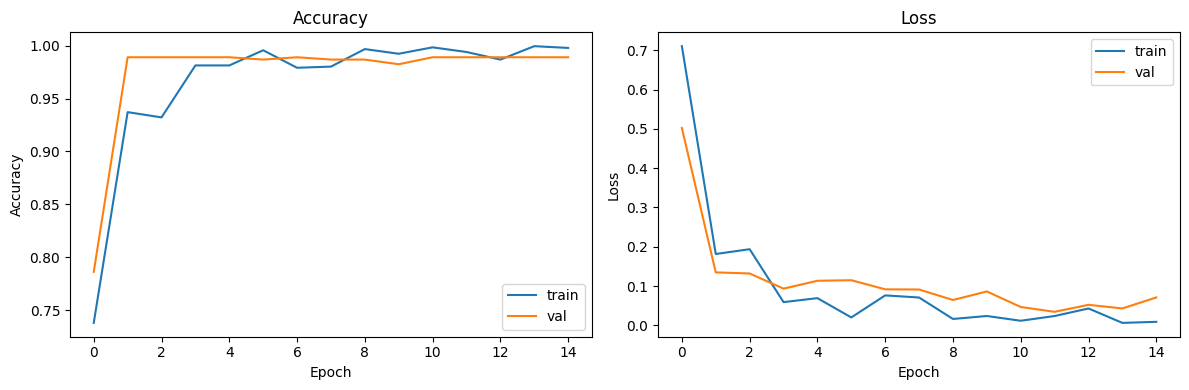

In [11]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout(); plt.show()


## 12. Hold-out test evaluation


In [12]:
test_loss, test_accuracy = model.evaluate(X_test_final, y_test, verbose=0)
print(f'Hold-out test loss:     {test_loss:.4f}')
print(f'Hold-out test accuracy: {test_accuracy:.4f}')

y_pred = np.argmax(model.predict(X_test_final, verbose=0), axis=1)
print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))


Hold-out test loss:     0.0013
Hold-out test accuracy: 1.0000

Confusion matrix:
[[6 0 0 0 0 0 0]
 [0 6 0 0 0 0 0]
 [0 0 6 0 0 0 0]
 [0 0 0 6 0 0 0]
 [0 0 0 0 6 0 0]
 [0 0 0 0 0 6 0]
 [0 0 0 0 0 0 6]]

Classification report:
                      precision    recall  f1-score   support

        Double_Lower       1.00      1.00      1.00         6
      Double_Nothing       1.00      1.00      1.00         6
Double_Pistol_Recoil       1.00      1.00      1.00         6
        Double_Raise       1.00      1.00      1.00         6
       Double_Wiggle       1.00      1.00      1.00         6
        Double_cmere       1.00      1.00      1.00         6
           Drum_Roll       1.00      1.00      1.00         6

            accuracy                           1.00        42
           macro avg       1.00      1.00      1.00        42
        weighted avg       1.00      1.00      1.00        42



## 13. Batch test on TestData/Jestin/TwoHandDynamic

The test folder contains one subfolder per gesture (matching the training class names, sometimes with case differences). We use **the subfolder name** as the ground-truth label — this is far more robust than parsing filenames. Class-name matching is case-insensitive so e.g. `TwoHandDynamic_L_Fist_R_LightBulb` (test) maps to `TwoHandDynamic_L_Fist_R_Lightbulb` (training).


In [13]:
def preprocess_csv_for_cnn(fpath, sensor_cols, resample_n, apply_butter, cutoff, order, fs, scaler,
                            seq_len, n_chan):
    """Read one CSV → (1, seq_len, n_chan) tensor ready for model.predict."""
    df = pd.read_csv(fpath)
    available = [c for c in sensor_cols if c in df.columns]
    if not available:
        raise ValueError('No matching sensor columns')
    if len(available) != len(sensor_cols):
        # Pad missing columns with zeros so the channel order matches training
        data = np.zeros((len(df), len(sensor_cols)), dtype=np.float32)
        idx_map = {c: i for i, c in enumerate(sensor_cols)}
        for c in available:
            data[:, idx_map[c]] = df[c].values.astype(np.float32)
    else:
        data = df[sensor_cols].values.astype(np.float32)

    if resample_n is not None:
        data = resample_trial(data, resample_n)
    if apply_butter:
        data = apply_butterworth([data], cutoff, order, fs)[0]
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    if scaler is not None:
        data = scaler.transform(data.reshape(1, -1)).reshape(seq_len, n_chan).astype(np.float32)

    return data.reshape(1, seq_len, n_chan)


def build_test_label_map(class_names):
    """Case-insensitive map from test-folder class name → training class name."""
    m = {}
    for cls in class_names:
        m[cls.lower()] = cls
    return m


def run_batch_test(test_root, model, scaler, le, sensor_cols, class_names,
                   resample_n, apply_butter, cutoff, order, fs, seq_len, n_chan):
    test_root = os.path.expanduser(test_root)
    if not os.path.isdir(test_root):
        raise FileNotFoundError(f'BATCH_TEST_ROOT not found: {test_root!r}')

    label_map = build_test_label_map(class_names)
    sub_dirs = sorted(d for d in os.listdir(test_root)
                      if os.path.isdir(os.path.join(test_root, d)))
    if not sub_dirs:
        print(f'No subfolders found in {test_root}')
        return None

    correct, total, unrecognised = 0, 0, 0
    per_class = {}
    rows = []
    print(f'Batch testing files from {len(sub_dirs)} subfolders under {test_root}')
    print('-' * 100)

    for sub in sub_dirs:
        true_label = label_map.get(sub.lower())
        sub_path = os.path.join(test_root, sub)
        csv_files = sorted(f for f in glob.glob(os.path.join(sub_path, '*.csv'))
                           if not os.path.basename(f).startswith('_'))
        if true_label is None:
            print(f'  ? subfolder {sub!r} has no matching training class — skipping ({len(csv_files)} files)')
            unrecognised += len(csv_files)
            continue

        per_class.setdefault(true_label, {'correct': 0, 'total': 0})

        for fpath in csv_files:
            fname = os.path.basename(fpath)
            try:
                x = preprocess_csv_for_cnn(
                    fpath, sensor_cols,
                    resample_n, apply_butter, cutoff, order, fs,
                    scaler, seq_len, n_chan,
                )
                probs = model.predict(x, verbose=0)[0]
                pred_idx = int(np.argmax(probs))
                pred = le.inverse_transform([pred_idx])[0]
                conf = float(probs.max())
                ok = (pred == true_label)
                correct += int(ok); total += 1
                per_class[true_label]['correct'] += int(ok)
                per_class[true_label]['total']   += 1
                rows.append({'file': fname, 'true': true_label, 'pred': pred,
                             'confidence': conf, 'correct': ok})
                tag = '✓' if ok else '✗'
                t_short = true_label.replace('TwoHandDynamic_', '')
                p_short = pred.replace('TwoHandDynamic_', '')
                print(f'  {tag} {fname[:50]:<52}  true={t_short:<28}  pred={p_short:<28}  conf={conf:.3f}')
            except Exception as e:
                print(f'  ERROR {fname}: {e}')

    print('-' * 100)
    if total > 0:
        print(f'Overall batch accuracy: {correct/total:.4f}  ({correct}/{total})')
    if unrecognised:
        print(f'Files in unmatched subfolders: {unrecognised}')

    print('\nPer-class accuracy:')
    for cls, d in sorted(per_class.items()):
        if d['total']:
            print(f'  {cls:<55} {d["correct"]/d["total"]:.4f}  ({d["correct"]}/{d["total"]})')

    return pd.DataFrame(rows), correct, total


batch_results = run_batch_test(
    BATCH_TEST_ROOT, model, scaler, le,
    SENSOR_COLS, class_names,
    RESAMPLE_TO_N_STEPS, APPLY_BUTTERWORTH, BUTTERWORTH_CUTOFF_HZ, BUTTERWORTH_ORDER,
    SAMPLING_RATE_HZ, sequence_length, n_channels,
)

if batch_results is not None:
    batch_df, batch_correct, batch_total = batch_results
    batch_test_accuracy = batch_correct / batch_total if batch_total else 0.0
else:
    batch_df, batch_test_accuracy = None, None


Batch testing files from 7 subfolders under /home/jestin/ThesisRepo/ML/NewTestData/Tash/Dynamic
----------------------------------------------------------------------------------------------------
  ✗ glove_data_L_Dynamic_Double_Lower_3s_1_2026-05-04_    true=Double_Lower                  pred=Double_Wiggle                 conf=0.993
  ✗ glove_data_L_Dynamic_Double_Lower_3s_2_2026-05-04_    true=Double_Lower                  pred=Double_Wiggle                 conf=0.998
  ✗ glove_data_L_Dynamic_Double_Lower_3s_3_2026-05-04_    true=Double_Lower                  pred=Double_Wiggle                 conf=0.996
  ✗ glove_data_L_Dynamic_Double_Lower_3s_4_2026-05-04_    true=Double_Lower                  pred=Double_Wiggle                 conf=0.998
  ✗ glove_data_L_Dynamic_Double_Lower_3s_5_2026-05-04_    true=Double_Lower                  pred=Double_Wiggle                 conf=0.997
  ✗ glove_data_L_Dynamic_Double_Nothing_3s_1_2026-05-0    true=Double_Nothing                pred=Double_cme

## 14. Save model and append experiment row to CSV log


In [14]:
def _to_jsonable(obj):
    if isinstance(obj, dict):  return {str(k): _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [_to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):    return obj.tolist()
    if isinstance(obj, np.integer):    return int(obj)
    if isinstance(obj, np.floating):   return float(obj)
    if isinstance(obj, np.bool_):      return bool(obj)
    return obj


def _stable_json(obj):
    return json.dumps(_to_jsonable(obj), sort_keys=True, separators=(',', ':'))


def build_experiment_row():
    hist = {k: [float(v) for v in vs] for k, vs in history.history.items()}
    row = {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'data_root': str(DATA_ROOT),
        'batch_test_root': str(BATCH_TEST_ROOT),
        'sensor_cols_count': len(SENSOR_COLS),
        'sensor_cols': _stable_json(SENSOR_COLS),
        'resample_to_n_steps': RESAMPLE_TO_N_STEPS,
        'apply_butterworth': bool(APPLY_BUTTERWORTH),
        'butterworth_cutoff_hz': BUTTERWORTH_CUTOFF_HZ,
        'butterworth_order': BUTTERWORTH_ORDER,
        'sampling_rate_hz': SAMPLING_RATE_HZ,
        'normalisation': NORMALISATION,
        'test_size': float(TEST_SIZE),
        'random_state': int(RANDOM_STATE),
        'cv_folds': int(CV_FOLDS),
        'run_cross_validation': bool(RUN_CROSS_VALIDATION),
        'cv_shuffle': bool(CV_SHUFFLE),
        'augment_training_data': bool(AUGMENT_TRAINING_DATA),
        'augmentation_copies_per_sample': int(AUGMENTATION_COPIES_PER_SAMPLE),
        'augmentation_random_seed': int(AUGMENTATION_RANDOM_SEED),
        'augmentation_config': _stable_json(AUGMENT_CONFIG),
        'n_classes': int(n_classes),
        'class_names': _stable_json(list(le.classes_)),
        'n_total_samples': int(X.shape[0]),
        'n_train_pool_samples': int(X_train_pool.shape[0]),
        'n_train_after_aug': int(X_train_final.shape[0]),
        'n_test_samples': int(X_test.shape[0]),
        'sequence_length': int(sequence_length),
        'n_channels': int(n_channels),
        'epochs': int(TRAIN_EPOCHS),
        'batch_size': int(TRAIN_BATCH_SIZE),
        'validation_split': float(TRAIN_VALIDATION_SPLIT),
        'cv_mean_accuracy': cv_mean_accuracy,
        'cv_std_accuracy': cv_std_accuracy,
        'cv_best_fold_index': best_cv_fold_index,
        'cv_fold_results_json': _stable_json(cv_fold_results),
        'cv_histories_json': _stable_json(cv_histories),
        'final_train_accuracy': float(history.history['accuracy'][-1]),
        'final_val_accuracy':   float(history.history['val_accuracy'][-1]),
        'final_train_loss':     float(history.history['loss'][-1]),
        'final_val_loss':       float(history.history['val_loss'][-1]),
        'best_val_accuracy':    float(max(history.history['val_accuracy'])),
        'best_val_loss':        float(min(history.history['val_loss'])),
        'test_accuracy':        float(test_accuracy),
        'test_loss':            float(test_loss),
        'batch_test_accuracy':  float(batch_test_accuracy) if batch_test_accuracy is not None else None,
        'history_json': _stable_json(hist),
    }
    sig_payload = {k: v for k, v in row.items() if k != 'timestamp'}
    row['row_signature'] = hashlib.sha256(_stable_json(sig_payload).encode()).hexdigest()
    return row


def append_experiment_row(csv_path=EXPERIMENT_LOG_PATH):
    row = build_experiment_row()
    df_new = pd.DataFrame([row])
    if csv_path.exists():
        df_existing = pd.read_csv(csv_path)
        if 'row_signature' in df_existing.columns and row['row_signature'] in set(df_existing['row_signature'].astype(str)):
            print(f'Identical row already in {csv_path} — not appending.')
            return df_existing
        df_out = pd.concat([df_existing, df_new], ignore_index=True)
    else:
        df_out = df_new
    df_out.to_csv(csv_path, index=False)
    print(f'Experiment log: {csv_path} ({len(df_out)} rows)')
    return df_out


def save_model_artifact():
    timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    sig = build_experiment_row()['row_signature'][:12]
    path = MODEL_OUTPUT_DIR / f'cnn_model_{timestamp}_{sig}.keras'
    model.save(path)
    print(f'Saved model to {path}')
    return path


model_path = save_model_artifact()
experiment_log_df = append_experiment_row()
experiment_log_df.tail(3)


Saved model to saved_models/cnn_model_2026-05-04_12-57-30_c3091d673086.keras
Experiment log: saved_models/experiment_results.csv (3 rows)


,timestamp,data_root,batch_test_root,sensor_cols_count,sensor_cols,resample_to_n_steps,apply_butterworth,butterworth_cutoff_hz,butterworth_order,sampling_rate_hz,...,final_val_accuracy,final_train_loss,final_val_loss,best_val_accuracy,best_val_loss,test_accuracy,test_loss,batch_test_accuracy,history_json,row_signature
0,2026-05-04 08:55:53,/home/jestin/ThesisRepo/ML/NewTrainingData/Dyn...,/home/jestin/ThesisRepo/ML/NewTestData/Tash/Dy...,280,"[""left_wrist_heading"",""left_wrist_pitch"",""left...",90,True,5.0,4,30.0,...,0.987981,0.053158,0.106469,0.987981,0.038123,1.0,0.008012,0.285714,"{""accuracy"":[0.8523752093315125,0.966325938701...",72e9abe01d3ac1bf13bc79159acaea61b8b2522236c06d...
1,2026-05-04 09:04:41,/home/jestin/ThesisRepo/ML/NewTrainingData/Dyn...,/home/jestin/ThesisRepo/ML/NewTestData/Tash/Dy...,176,"[""left_wrist_heading"",""left_wrist_pitch"",""left...",90,True,10.0,4,30.0,...,0.986784,0.007987,0.055267,0.988987,0.055267,1.0,0.001524,0.257143,"{""accuracy"":[0.6576626300811768,0.928335189819...",3a6fa90178c2dd214c4d78bcc6723fc1bade831145b9cc...
2,2026-05-04 12:57:30,/home/jestin/ThesisRepo/ML/NewTrainingData/Dyn...,/home/jestin/ThesisRepo/ML/NewTestData/Tash/Dy...,176,"[""left_wrist_heading"",""left_wrist_pitch"",""left...",90,True,10.0,4,30.0,...,0.988987,0.008824,0.070857,0.988987,0.034294,1.0,0.001296,0.428571,"{""accuracy"":[0.7381477355957031,0.937155485153...",c3091d673086db3e780ce09fa3ec07ecdd0156a6dffde3...
